# Early stopping and Multiple Hypothesis Tests


In this simulation study, we examined the statistical challenges of sequential experimentation and repeated hypothesis testing in the context of an online A/B test. We considered a setting in which an online travel company, such as Airbnb or Booking.com, evaluates whether replacing Upfront Fees (control group) with Back-End Fees (treatment group) increases the probability of purchase. The data generating process assumed a baseline purchase probability of 7% under the control condition and a true treatment effect of 1.5 percentage points under the treatment condition.

We first conducted a statistical power analysis to determine the minimum sample size required to detect the true treatment effect with 80% power at a 5% significance level. Using this sample size, we simulated experiments in which observations arrived sequentially in batches of 500 users. After each batch, we estimated the Average Treatment Effect (ATE) using the Simple Difference in Outcomes (SDO) estimator and calculated p-values using a proportions z-test.

The primary objective of the simulation was to study the consequences of repeated interim testing and optional stopping. In the first approach, experiments were monitored continuously and stopped as soon as a statistically significant result was observed. We repeated this sequential procedure across 200 simulated experiments and analyzed the distribution of the first significant treatment effect estimates, the frequency of significance, and the extent of stopping bias caused by repeated peeking at the data.

In the second approach, we removed early stopping and instead evaluated only the final test at the predetermined full sample size. This allowed us to compare sequential monitoring against a fixed-sample testing framework and examine how repeated interim testing affects statistical significance rates, estimation bias, and the reliability of treatment effect estimates.

In a nutsell, the simulation illustrates the tradeoff between early decision-making and statistical reliability, highlighting how naive repeated testing can inflate significance rates and exaggerate estimated treatment effects, while fixed final testing better preserves the intended statistical properties of hypothesis testing.

In [2]:
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.power import zt_ind_solve_power


def gen_data(n, p_treated, p_purchase, treatment_effect):

    df = pd.DataFrame({
        "visit_ID": np.arange(n),
        "BF": np.random.choice([0, 1], p=[1 - p_treated, p_treated], size=n)
    })

    df["purchase"] = 0

    p_purchase_t = p_purchase + treatment_effect

    df.loc[df["BF"] == 0, "purchase"] = np.random.choice(
        [0, 1],
        p=[1 - p_purchase, p_purchase],
        size=len(df[df["BF"] == 0])
    )

    df.loc[df["BF"] == 1, "purchase"] = np.random.choice(
        [0, 1],
        p=[1 - p_purchase_t, p_purchase_t],
        size=len(df[df["BF"] == 1])
    )

    return df


df = gen_data(n=1000, p_treated=0.5, p_purchase=0.07, treatment_effect=0.015)
df

,visit_ID,BF,purchase
0,0,0,0
1,1,0,0
2,2,0,0
3,3,0,0
4,4,0,0
...,...,...,...
995,995,0,0
996,996,1,0
997,997,0,0
998,998,1,0


In [3]:
from statsmodels.stats.proportion import proportion_effectsize

alpha = 0.05
power = 0.80

prop_control = 0.07
prop_treatment = 0.085

effect_size = proportion_effectsize(prop_treatment, prop_control)

n_per_group = zt_ind_solve_power(
    effect_size=effect_size,
    alpha=alpha,
    power=power,
    ratio=1,
    alternative="larger"
)

total_sample_size = 2 * n_per_group
#n_total = np.ceil(n_per_group * 2)

print(f"Minimum sample size per group: {np.ceil(n_per_group):.0f}")
print(f"Minimum total sample size needed for 80% power: {np.ceil(total_sample_size):.0f}")

Minimum sample size per group: 3921
Minimum total sample size needed for 80% power: 7841


# Minimum Sample Size for Detecting a Conversion Lift

In this problem, we want to determine how many users (smaple size or n) are needed so that we can reliably detect a small increase in conversion rate:

$$
7\% \rightarrow 8.5\%
$$

We compare two probabilities:

$$
p_c = 0.07 \qquad \text{(control)}
$$

$$
p_t = 0.085 \qquad \text{(treatment)}
$$

The outcome is binary : we have Purchase = 1  and  No purchase = 0 . So each observation follows a **Bernoulli distribution**.

**The key challenge is that purchase is a binary outcome (0 or 1), so it is inherently noisy. Even if the true difference is 1.5 percentage points, the observed difference will fluctuate due to randomness.**

---

We want to know **How large should the sample size be so that the true treatment effect is large enough relative to random noise, allowing us to detect it with 80% probability?**

---

#### For a Bernoulli random variable:

$$
Var(Y) = p(1-p)
$$

So:

### Control group variance

$$
Var(Y_c) = p_c(1-p_c)
$$

$$
= 0.07(1-0.07)
$$

$$
= 0.0651
$$

---

### Treatment group variance

$$
Var(Y_t) = p_t(1-p_t)
$$

$$
= 0.085(1-0.085)
$$

$$
= 0.0778
$$

---

#### Standard Error (Noise Level)

When estimating a proportion using \(n\) observations:

$$
SE(\hat p) \approx \sqrt{\frac{p(1-p)}{n}}
$$

As \(n\) increases: Noise decreases and Estimates become more stable  

---

#### Standard Error of Difference in Proportions

For two independent groups:

$$
SE(\hat p_t - \hat p_c)
=
\sqrt{
\frac{p_t(1-p_t)}{n}
+
\frac{p_c(1-p_c)}{n}
}
$$

This measures the randomness in the estimated treatment effect.

---

#### What the Statistical Test Is Doing

We are effectively testing whether:

$$
\frac{\hat p_t - \hat p_c}
{SE(\hat p_t - \hat p_c)}
> z_\alpha
$$

And we want this to happen:

$$
80\%
$$

of the time when the true effect is:

$$
p_t - p_c = 0.015
$$

---

#### Inverse Formula for Sample Size

The function `zt_ind_solve_power()` is solving for \(n\) in:

$$
n
\approx
\frac{
(z_{1-\alpha/2}+z_{1-\beta})^2
\left[
p_c(1-p_c)+p_t(1-p_t)
\right]
}
{
(p_t-p_c)^2
}
$$

where:

- \(\alpha = 0.05\) → significance level  
- \(\beta = 0.20\) → power \(=1-\beta=0.80\)  

Critical values:

$$
z_{1-\alpha/2} \approx 1.96
$$

$$
z_{1-\beta} \approx 0.84
$$

---

This formula shows:

- Larger variance → larger \(n\)  
- Smaller effect size → larger \(n\)  
- Stricter confidence level → larger \(n\)  
- Higher power → larger \(n\)  

---

In this experiment:

- Effect size is small:

$$
0.085 - 0.07 = 0.015
$$

- Outcome is noisy (binary) So a large sample is needed to separate: True signal from Random variation  

---


Minimum sample size per group:

$$
n \approx 3921
$$

Total sample size:

$$
N \approx 7841
$$



This means: About 3921 users in control and About 3921 users in treatment are needed.

So:

$$
3921 + 3921 \approx 7841
$$

total users are required. So as a result we can say A 1.5 percentage point increase is small relative to the randomness of binary outcomes, so thousands of users are needed to reliably detect it.

In [9]:
#  ATE using Simple Difference in Outcomes(SDO)

# first batch of 500 observations
df_batch = gen_data(
    n=500,
    p_treated=0.5,
    p_purchase=0.07,
    treatment_effect=0.015
)


mean_treatment = df_batch[df_batch["BF"] == 1]["purchase"].mean()

mean_control = df_batch[df_batch["BF"] == 0]["purchase"].mean()

# Simple Difference in Outcomes / ATE
ate = mean_treatment - mean_control

print("Treatment mean:", mean_treatment)
print("Control mean:", mean_control)
print("Estimated ATE:", ate)

Treatment mean: 0.12033195020746888
Control mean: 0.05791505791505792
Estimated ATE: 0.062416892292410965


In [10]:
# Using proportions z-test to calculate the p-value to see if it is the result statistically significant?

from statsmodels.stats.proportion import proportions_ztest

# Number of purchases in each group
success_treatment = df_batch[df_batch["BF"] == 1]["purchase"].sum()
success_control = df_batch[df_batch["BF"] == 0]["purchase"].sum()

# Number of observations in each group
n_treatment = df_batch[df_batch["BF"] == 1].shape[0]
n_control = df_batch[df_batch["BF"] == 0].shape[0]

# successes and sample sizes into arrays
count = np.array([success_treatment, success_control])
nobs = np.array([n_treatment, n_control])

#  z-test
z_stat, p_value = proportions_ztest(
    count=count,
    nobs=nobs,
    alternative="larger"
)

print("Z-statistic:", z_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("The result is statistically significant.")
else:
    print("The result is not statistically significant.")

Z-statistic: 2.461709419656793
P-value: 0.006913832277715778
The result is statistically significant.


In [17]:
from statsmodels.stats.proportion import proportions_ztest

total_sample_size = 7841
batch_size = 500

# Number of batches needed
num_iterations = int(np.ceil(total_sample_size / batch_size))


sdo_list = []
pvalue_list = []
sample_size_list = []

#  dataframe to store cumulative data
df_all = pd.DataFrame()

for i in range(num_iterations):

    #new batch of 500 observations
    df_new = gen_data(
        n=batch_size,
        p_treated=0.5,
        p_purchase=0.07,
        treatment_effect=0.015
    )

    # Appending new batch to old data
    df_all = pd.concat([df_all, df_new], ignore_index=True)

    #  SDO / ATE
    mean_treatment = df_all[df_all["BF"] == 1]["purchase"].mean()
    mean_control = df_all[df_all["BF"] == 0]["purchase"].mean()

    sdo = mean_treatment - mean_control

    #p-value using proportions z-test
    success_treatment = df_all[df_all["BF"] == 1]["purchase"].sum()
    success_control = df_all[df_all["BF"] == 0]["purchase"].sum()

    n_treatment = df_all[df_all["BF"] == 1].shape[0]
    n_control = df_all[df_all["BF"] == 0].shape[0]

    count = np.array([success_treatment, success_control])
    nobs = np.array([n_treatment, n_control])

    z_stat, p_value = proportions_ztest(
        count=count,
        nobs=nobs,
        alternative="larger"
    )

    
    sdo_list.append(sdo)
    pvalue_list.append(p_value)
    sample_size_list.append(df_all.shape[0])

In [19]:
for i in range(len(pvalue_list)):
    if pvalue_list[i] < 0.05:
        print("First statistically significant result:")
        print("Iteration:", i + 1)
        print("Sample size:", sample_size_list[i])
        print("SDO:", sdo_list[i])
        print("P-value:", pvalue_list[i])
        break        

First statistically significant result:
Iteration: 6
Sample size: 3000
SDO: 0.020578669956263312
P-value: 0.01660198487791269


In [20]:
results = pd.DataFrame({
    "iteration": np.arange(1, num_iterations + 1),
    "sample_size": sample_size_list,
    "SDO": sdo_list,
    "p_value": pvalue_list
})

results

,iteration,sample_size,SDO,p_value
0,1,500,0.019984,0.193791
1,2,1000,0.009044,0.292485
2,3,1500,0.008596,0.258020
3,4,2000,0.013642,0.124132
4,5,2500,0.014402,0.081370
5,6,3000,0.020579,0.016602
6,7,3500,0.020371,0.011869
7,8,4000,0.022354,0.003926
8,9,4500,0.021676,0.003154
9,10,5000,0.023040,0.001239


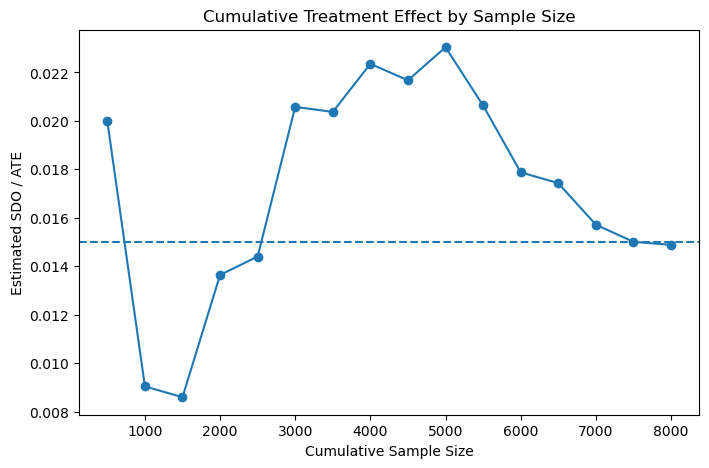

In [21]:
plt.figure(figsize=(8, 5))
plt.plot(results["sample_size"], results["SDO"], marker="o")
plt.axhline(y=0.015, linestyle="--")
plt.xlabel("Cumulative Sample Size")
plt.ylabel("Estimated SDO / ATE")
plt.title("Cumulative Treatment Effect by Sample Size")
plt.show()

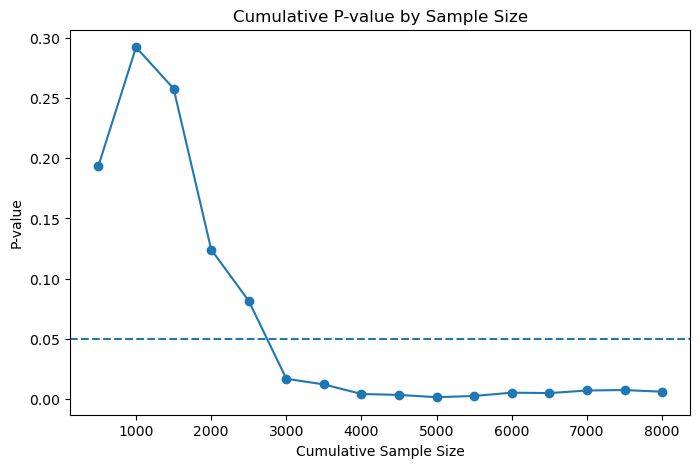

In [22]:
plt.figure(figsize=(8, 5))
plt.plot(results["sample_size"], results["p_value"], marker="o")
plt.axhline(y=0.05, linestyle="--")
plt.xlabel("Cumulative Sample Size")
plt.ylabel("P-value")
plt.title("Cumulative P-value by Sample Size")
plt.show()

### True ATE vs Observed SDO in Experiments

In the first part, we are effectively acting like **omniscient observers** because we know the true data-generating process.

We know that the true Average Treatment Effect (ATE) is exactly:

$$
0.085 - 0.07 = 0.015
$$

So the power calculation asks: **How many observations are needed so that we can reliably detect this true effect with 80% probability?**

The answer was:

$$
N \approx 7841
$$

total observations.

---

### in a Real Experiment:

In a simulated or real experiment, we do **not** observe the true ATE directly. Instead, we observe the sample estimate:

$$
SDO = \hat p_t - \hat p_c
$$

where:

- $\hat p_t$ = observed treatment conversion rate  
- $\hat p_c$ = observed control conversion rate  

---

### Observed Effect Fluctuates

Because the data is random and different samples produce different estimates and small samples can fluctuate substantially  So even if the true effect is:

$$
ATE = 0.015
$$

the observed estimate may differ.

In this simulation:

$$
SDO \approx 0.031
$$

which is much larger than the true effect.

---

This happened because of: **Random sampling variability** NOT because the estimator is biased which means:

As sample size increases:

- 1-- Random fluctuations shrink  
- 2- The estimate becomes more stable  
- 3- The estimate moves closer to the true ATE  

This follows the Law of Large Numbers.

Variability Shrinks

The standard error decreases approximately as:

$$
SE \propto \frac{1}{\sqrt{n}}
$$

So:

- Larger n → smaller noise  
- Smaller noise → more accurate estimates  

---

#### As a simple footnote :

A statistically significant p-value does **NOT** necessarily mean: The estimated effect is numerically close to the true effect.  

It only means: **The observed effect is statistically distinguishable from zero.** But we need add more obeseravtion or increase sample size to lower variance and help maybe SDE gets close to ATE. As we found this increase of sample size can 
reach SDE close to ATE in approimately 7841 number of observations. 

---
### As another footnote and remainder :

Under random assignment:

$$
E[SDO] = ATE
$$

So the estimator is already approximately **unbiased**. But The issue in small samples is mainly:

- High variance  
- Random fluctuation  

not systematic bias.

## Graphs:

In the p-value graph we see around sample size = 3000, the p-value drops below 0.05, so the result becomes statistically significant.

But in the ATE plot we see something important that The estimated treatment effect does not move close to the true ATE of 0.015. Instead, after 3000 observations, it gets around 0.015 but it is bt chance or randomly happened because after theis 
expriment continues we see that the value goes up and thenn fall untill it gets fixed or stable in the last batches. 

This can happen because of random sampling variation. “Larger sample size gets closer to the true ATE” means on**average across many repeated simulations, not necessarily in every single simulated experiment.**

In the simulated experiment, the early batches produced a relatively high treatment effect. Once those early observations are included in df_all, they remain in the cumulative dataset. So even when we add more data, the estimate may come down only slowly.

For example at around 1500, SDO is less than 0.01. At 2000, a new batch pushes SDO up to about 0.015. After that, more data reduces the noise, but the cumulative estimate stays around 0.015( this value that is the same as True ATE happened by chance here because in the next run it can be 0.25 but the thing is that this value would get fix aftr w a more data.) **so adding more data reduce noise and make the reslut doesnt fluctute a lot and trend get flat but with just one expriment or simulation maybe we can not reach SDE cose to ATE even we follow the sample size that power calculation recommneded us like approximately 8000 . **

So the key point is:

$$
SDO \rightarrow ATE
$$

as sample size gets very large, but 8000 may still not be large enough in one random run to guarantee closeness.

Also, statistical significance and accuracy are different:

p-value < 0.05 means the effect is statistically different from zero. It does not mean the estimated effect is close to the true effect.

In the plots, the result becomes significant because the estimated SDO is much larger than the true effect:

$$
0.026 > 0.015
$$

So the test is strongly significant, but the estimate is still too high.


As a result we can say the p-value becomes statistically significant around 3000 observations because the observed SDO jumps above the true ATE. However, the cumulative treatment effect does not necessarily converge smoothly to 0.015 in one simulation. Larger samples reduce sampling noise on average, but a single realized experiment can still remain above or below the true effect, especially when early batches strongly influence the cumulative estimate.

#### As a short point : 

Adding 500 Observations Each Iteration Dosed not Mean We Repeated the Experiment. It is still:

$$
\text{ONE single experiment}
$$

We are simply observing the same experiment over time as more users arrive.

So:

- Iteration 1 → first 500 users  
- Iteration 2 → first 1000 users  
- Iteration 3 → first 1500 users  

and so on.

The data is cumulative:

$$
D_{2000} = D_{1500} + \text{new 500 users}
$$

So this is: one growing experiment not repeated independent experiments.  

---

#### Another footnote is: 

we can ask ourselves is  “8000 observations are enough to make SDO close to the true ATE.”

The naswer is this is **not guaranteed** for one single experiment.More accurately: 8000 observations make SDO likely to be close to ATE not guaranteed.

Power / Sample Size saying in our simulation  “If the true ATE = 0.015, then with about 8000 observations we will detect it with 80% probability.” This probability refers to many hypothetical repeated experiments not one specific experiment. 


The SDO is a random variable:

$$
SDO = \hat p_t - \hat p_c
$$

Every time we run a new experiment, we get a different SDO like 


| Experiment | SDO |
|---|---|
| 1 | 0.026 |
| 2 | 0.011 |
| 3 | 0.017 |
| 4 | 0.014 |
| 5 | 0.020 |

All are generated from the same true effect:

$$
ATE = 0.015
$$



But if we run 1000 independent experiments and each with 8000 observations and compute SDO each time.

Then:

$$
\frac{1}{1000}\sum_{i=1}^{1000} SDO_i \approx 0.015
$$

because:

$$
E[SDO] = ATE
$$

This is the unbiasedness property.

so there are TWO different meanings of “getting close.”


##### 1. One Single Experiment

In one experiment:

$$
SDO \neq ATE
$$

possibly even with 8000 observations.The estimate may still fluctuate.


##### 2. Average Across Many Experiments

Across repeated experiments:

$$
\text{Average}(SDO) \rightarrow ATE
$$

This follows Law of Large Numbers and Unbiased estimation  

---

So increasing sample size does NOT guarantee:

$$
SDO = ATE
$$

Instead, it reduces variance:

$$
Var(SDO) \downarrow
$$

Equivalently:

$$
SE \propto \frac{1}{\sqrt{n}}
$$

So the distribution of possible SDO values becomes tighter around:

$$
0.015
$$



So we need to remeber he cumulative experiment in batches is still one single experiment, not repeated experiments.

The sample size calculation of approximately 8000 observations does not guarantee that one realized SDO will equal the true ATE of 0.015. Instead, it implies that:

- The estimator has lower variance  
- The experiment has a high probability of detecting the effect statistically  

To observe convergence more clearly, we would need to:

- Repeat the entire experiment many times  
- Use 8000 observations in each experiment  
- Average the resulting SDO estimates

### As another quick reminder : 

In real-world experiments, we usually observe only one realized experiment, so we cannot directly see the entire sampling distribution by rerunning reality many times.

Because of that, we rely on tools such as:

- Power analysis  
- P-values  
- Confidence intervals  
- Standard errors  
- Randomization theory  

to reason about uncertainty.

---

We do not “just trust the p-value.” Good experimental analysis combines several components:


- **1. Power Calculation (Before the Experiment) : Determines whether the experiment is large enough to reliably detect meaningful effects.**


- **2. Point Estimate (SDO / ATE Estimate) : Tells us the estimated size of the treatment effect.**

In your experiment we have  true parameter = true ATE  and  estimator = SDO  So:

$$
SDO = \hat p_t - \hat p_c
$$

is a point estimate of:

$$
ATE
$$

because it gives one specific number.

Example:

$$
\text{Estimated treatment effect} = 0.026
$$

That single value is the point estimate.

It is called “point” because it gives one point/value instead of a range like : 

| Concept | Example |
|:---|:---|
| Point estimate | $$ATE \approx 0.026$$ |
| Confidence interval | $$ATE \in [0.010,\ 0.042]$$ |

The interval reflects uncertainty.


- **3. Standard Error / Confidence Interval :  Tells us how uncertain the estimate is.**


-  **4. P-value : Tells us whether the observed effect is statistically distinguishable from zero.**

---

In practice, we are trying to answer: “What range of true treatment effects is plausible given the one experiment we observed?”

---

Even though we only observe one real experiment:

- P-values  
- Confidence intervals  

are mathematically defined using the idea of: “What would happen if we repeated this experiment infinitely many times?”

For example, when we say:

$$
p < 0.05
$$

we mean: **If the true treatment effect were actually zero, then obtaining a result this extreme would occur in fewer than 5% of repeated experiments.**


Confidence intervals are also defined through repeated hypothetical sampling. The idea is:

- If we repeated the experiment many times  
- And computed a confidence interval each time  

then approximately:

$$
95\%
$$

of those intervals would contain the true treatment effect.

---


So in practice, we only observe one realized experiment, so we cannot directly observe:

- The true ATE  
- The full sampling distribution of the estimator  

Therefore, we use:

- Power calculations before the experiment  
- P-values and confidence intervals after the experiment  

to reason probabilistically about whether the observed SDO likely reflects a real treatment effect rather than random sampling variation.

### As another reminder we can asl ourselves how do we do power analysis if we do not know the true ATE?

In real experiments: We do NOT know the true effect. So before the experiment, researchers must ASSUME or PROPOSE a plausible effect size usually based on:

- domain knowledge  
- previous studies  
- pilot experiments  
- business relevance  
- historical data  
- expert judgment  

---

This assumed effect is often called: **Minimum Detectable Effect (MDE)** which means “What is the smallest effect size that we care about detecting?”

like we saying “If Back-End Fees improve conversion by at least 1.5 percentage points, we care.” then 

$$
MDE = 0.015
$$

So power analysis becomes: “How large should the sample be to detect an effect of at least 0.015?”

Power calculations are hypothetical/planning tools. They are based on assumptions: assumed ATE and not known truth.

---

When we computed:

$$
n \approx 7841
$$

we were saying: **“IF the true effect is 0.015, then 7841 observations give us 80% power.”**

---

If the true effect were actually:

- $$0.03$$ → need much smaller sample  
- $$0.005$$ → need much larger sample  

---

In real world before experiments, companies often do NOT know:

- whether an effect exists  
- the magnitude of the effect  
- even the sign of the effect  

So MDE selection becomes partly:

- scientific judgment  
- business judgment  
- budget/resource tradeoff  

---

So: In practice, the true ATE is unknown before running an experiment, so power analysis cannot use the true effect directly. Instead, researchers specify an assumed effect size or Minimum Detectable Effect (MDE) based on prior studies, domain knowledge, pilot data, or business relevance. The power calculation then determines how many observations are needed to reliably detect an effect of at least that magnitude.

In [23]:
# Simulate 200 experiments and save first significant SDO and p-value


from statsmodels.stats.proportion import proportions_ztest
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

num_experiments = 200
total_sample_size = 7841
batch_size = 500
num_iterations = int(np.ceil(total_sample_size / batch_size))

first_sig_sdo_list = []
first_sig_pvalue_list = []
first_sig_iteration_list = []
first_sig_sample_size_list = []

for exp in range(num_experiments):

    df_all = pd.DataFrame()

    first_sig_sdo = np.nan
    first_sig_pvalue = np.nan
    first_sig_iteration = np.nan
    first_sig_sample_size = np.nan

    for i in range(num_iterations):

        df_new = gen_data(
            n=batch_size,
            p_treated=0.5,
            p_purchase=0.07,
            treatment_effect=0.015
        )

        df_all = pd.concat([df_all, df_new], ignore_index=True)

        mean_treatment = df_all[df_all["BF"] == 1]["purchase"].mean()
        mean_control = df_all[df_all["BF"] == 0]["purchase"].mean()

        sdo = mean_treatment - mean_control

        success_treatment = df_all[df_all["BF"] == 1]["purchase"].sum()
        success_control = df_all[df_all["BF"] == 0]["purchase"].sum()

        n_treatment = df_all[df_all["BF"] == 1].shape[0]
        n_control = df_all[df_all["BF"] == 0].shape[0]

        count = np.array([success_treatment, success_control])
        nobs = np.array([n_treatment, n_control])

        z_stat, p_value = proportions_ztest(
            count=count,
            nobs=nobs,
            alternative="larger"
        )

        if p_value < 0.05:
            first_sig_sdo = sdo
            first_sig_pvalue = p_value
            first_sig_iteration = i + 1
            first_sig_sample_size = df_all.shape[0]
            break

    first_sig_sdo_list.append(first_sig_sdo)
    first_sig_pvalue_list.append(first_sig_pvalue)
    first_sig_iteration_list.append(first_sig_iteration)
    first_sig_sample_size_list.append(first_sig_sample_size)

In [24]:
# histogram of estimated ATEs and calculate mean estimated ATE

sim_results = pd.DataFrame({
    "first_sig_sdo": first_sig_sdo_list,
    "first_sig_pvalue": first_sig_pvalue_list,
    "first_sig_iteration": first_sig_iteration_list,
    "first_sig_sample_size": first_sig_sample_size_list
})

sim_results.head()

,first_sig_sdo,first_sig_pvalue,first_sig_iteration,first_sig_sample_size
0,0.011367,0.028182,16.0,8000.0
1,0.019945,0.028410,5.0,2500.0
2,0.017721,0.042474,5.0,2500.0
3,0.061305,0.003244,1.0,500.0
4,0.025396,0.030680,3.0,1500.0


In [25]:
# Keeping only experiments that became significant
sig_results = sim_results.dropna()

mean_estimated_ate = sig_results["first_sig_sdo"].mean()

print("Mean estimated ATE among significant experiments:", mean_estimated_ate)
print("True ATE:", 0.015)

Mean estimated ATE among significant experiments: 0.027809654202651555
True ATE: 0.015


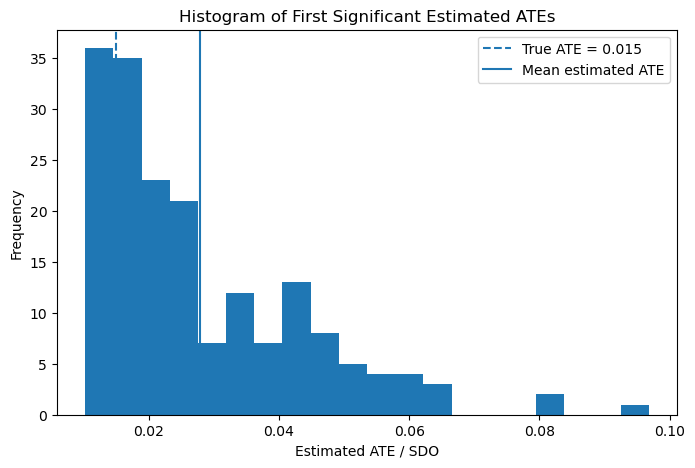

In [26]:
plt.figure(figsize=(8, 5))
plt.hist(sig_results["first_sig_sdo"], bins=20)
plt.axvline(0.015, linestyle="--", label="True ATE = 0.015")
plt.axvline(mean_estimated_ate, linestyle="-", label="Mean estimated ATE")
plt.xlabel("Estimated ATE / SDO")
plt.ylabel("Frequency")
plt.title("Histogram of First Significant Estimated ATEs")
plt.legend()
plt.show()

In [27]:
if mean_estimated_ate > 0.015:
    print("The first significant estimates are upward biased.")
else:
    print("The first significant estimates are not upward biased.")

The first significant estimates are upward biased.


In [28]:
# Percent of experiments significant at some point
percent_significant = sim_results["first_sig_pvalue"].notna().mean() * 100

print("Percent of experiments significant at some point:", percent_significant)
print("Expected based on 80% power:", 80)

Percent of experiments significant at some point: 90.5
Expected based on 80% power: 80


In [29]:
if percent_significant > 80:
    print("More than 80% became significant because we checked multiple times.")
else:
    print("Around 80% or fewer became significant.")

More than 80% became significant because we checked multiple times.


The earlier part we studied ONE realized experiment where data arrived sequentially:

$$
500 \rightarrow 1000 \rightarrow 1500 \rightarrow \dots \rightarrow 8000
$$

and we repeatedly checked significance. Now this new section asks: **What happens across MANY repeated experiments?**

So now we move from: one realized path to a distribution across many hypothetical experiments  which is the core idea behind frequentist statistics and statistical power.


The important note is this is only about the first sample size that becomes significant rather than the full 8000 sample.

This section is specifically studying:

- optional stopping  
- repeated testing  
- peeking bias 

The question is NOT primarily asking  “What is the final estimate at 8000?” Instead it asks: “At ANY point during the experiment, did we observe significance?”


Inside each experiment:

$$
500 \rightarrow \text{test}
$$

$$
1000 \rightarrow \text{test}
$$

$$
1500 \rightarrow \text{test}
$$

$$
\dots
$$

$$
8000 \rightarrow \text{test}
$$

We stop and record: the FIRST statistically significant SDO  and the FIRST significant p-value if significance ever occurs.


This is important Because repeated testing changes statistical behavior like :

- inflates false positives  
- changes effective power  

Even if one fixed test at 8000 observations has:

$$
80\% \text{ power}
$$

repeatedly testing every 500 observations creates many opportunities to cross the significance threshold.

The simulation is empirically studying:

$$
P(\text{significant at some point})
$$

across many repeated experiments.

Across the repeated experiments, we estimate:

- Distribution of observed SDOs  
- Frequency of significance  
- Whether the estimator is unbiased  
- Effect of sequential testing  

---

We are repeat 200 Experiments because one experiment is noisy. By repeating 200 times, we approximate the sampling distribution of:

$$
SDO
$$

Now we can empirically observe:

$$
E[SDO] \approx ATE
$$

which cannot be seen clearly from one single experiment.

---

Asa quick note we “Keep track of SDO and p-value the first time significance appears.”

This introduces **Selection Bias** because we only record experiments when they cross significance early.Early significance often happens when random noise temporarily inflates the estimated effect. So the first significant estimate often satisfies:

$$
SDO > ATE
$$

on average.This phenomenon is related to:

- Winner’s curse  
- Stopping bias  
- Optional stopping bias  

---
So in this section we addresses the idea that one realized experiment is noisy.By simulating many independent experiments, we approximate the sampling distribution of the estimator and study how repeated testing behaves across experiments. However, the focus is NOT mainly on the final estimate at 8000 observations. Instead, the simulation studies:

- the first time significance appears  
- the consequences of optional stopping  
- repeated hypothesis testing over time


As another short note is the problem that we can have both of we stop expriment and we continue expriment:

- if we stop expriment we need to be sure that this sigificance is not random or by chance or false positive or winner curse. 
- if we continue we are falling into the trap of increasing the chance to get more false positive or peekingbias problem.

## Result and histogram interpertation:

The histogram shows the distribution of the first significant estimated treatment effects across the 200 simulated experiments. The dashed vertical line is the true ATE=0.015 while the solid line is the average of the first significant SDO estimates.

The important result is **The mean first significant estimated ATE is larger than the true ATE.**

This means the “first significant” estimates are upward biased. As we laready mentioned this is happebning because significance tends to occur when random noise temporarily pushes the estimated treatment effect upward. Experiments where the SDO stays near the true value of 0.015 often do not become significant early, while experiments with unusually large estimated effects cross the significance threshold faster. Therefore, by recording only the first significant estimate, we systematically select exaggerated treatment effects.

This is a form of:

- stopping bias
- selection bias
- winner’s curse

The second result is also very important which is 90.5%>80% . 

The original power calculation predicted that approximately 80% of experiments would become significant if we conducted one fixed final test at the planned sample size. However, in the simulation we repeatedly tested the data after every additional batch of 500 observations. This gave randomness multiple opportunities(16×200=3200 dependent not indepndent oprtunities: just as a quick note we did not go for all 3200 because we used early stoping method which means once you hit the first significant p-valye, we can stop that expriment and go for another expriment and this can happen for example uin that batch of 6 instead of full batch which is 16) to produce a significant p-value. As a result, the probability of observing at least one significant result increased from the nominal 80% power to about 90.5%.

Asa result repeated sequential testing inflates the probability of significance compared to a single pre-planned test.
Stopping at the first significant result tends to exaggerate the estimated treatment effect because significance is more likely when random fluctuations temporarily inflate the SDO.

In [30]:
from statsmodels.stats.proportion import proportions_ztest
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

num_experiments = 200
total_sample_size = 7841
batch_size = 500
num_iterations = int(np.ceil(total_sample_size / batch_size))

final_sdo_list = []
final_pvalue_list = []

for exp in range(num_experiments):

    df_all = pd.DataFrame()

    for i in range(num_iterations):

        df_new = gen_data(
            n=batch_size,
            p_treated=0.5,
            p_purchase=0.07,
            treatment_effect=0.015
        )

        df_all = pd.concat([df_all, df_new], ignore_index=True)

    # final SDO after all batches
    mean_treatment = df_all[df_all["BF"] == 1]["purchase"].mean()
    mean_control = df_all[df_all["BF"] == 0]["purchase"].mean()

    final_sdo = mean_treatment - mean_control

    # final p-value after all batches
    success_treatment = df_all[df_all["BF"] == 1]["purchase"].sum()
    success_control = df_all[df_all["BF"] == 0]["purchase"].sum()

    n_treatment = df_all[df_all["BF"] == 1].shape[0]
    n_control = df_all[df_all["BF"] == 0].shape[0]

    count = np.array([success_treatment, success_control])
    nobs = np.array([n_treatment, n_control])

    z_stat, final_pvalue = proportions_ztest(
        count=count,
        nobs=nobs,
        alternative="larger"
    )

    final_sdo_list.append(final_sdo)
    final_pvalue_list.append(final_pvalue)

Mean estimated ATE: 0.01511210431239286
True ATE: 0.015


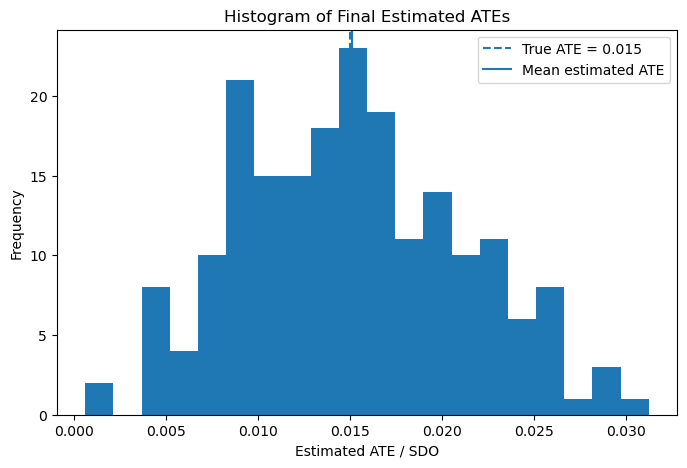

The estimate is slightly upward biased.


In [31]:
final_results = pd.DataFrame({
    "final_sdo": final_sdo_list,
    "final_pvalue": final_pvalue_list
})

mean_final_ate = final_results["final_sdo"].mean()

print("Mean estimated ATE:", mean_final_ate)
print("True ATE:", 0.015)

plt.figure(figsize=(8, 5))
plt.hist(final_results["final_sdo"], bins=20)
plt.axvline(0.015, linestyle="--", label="True ATE = 0.015")
plt.axvline(mean_final_ate, linestyle="-", label="Mean estimated ATE")
plt.xlabel("Estimated ATE / SDO")
plt.ylabel("Frequency")
plt.title("Histogram of Final Estimated ATEs")
plt.legend()
plt.show()

if mean_final_ate > 0.015:
    print("The estimate is slightly upward biased.")
elif mean_final_ate < 0.015:
    print("The estimate is slightly downward biased.")
else:
    print("The estimate is unbiased.")

In [32]:
percent_final_significant = (final_results["final_pvalue"] < 0.05).mean() * 100

print("Percent significant in final iteration:", percent_final_significant)
print("Expected based on 80% power:", 80)

if percent_final_significant > 80:
    print("This is slightly higher than expected, likely due to simulation randomness.")
elif percent_final_significant < 80:
    print("This is slightly lower than expected, likely due to simulation randomness.")
else:
    print("This matches the expected 80% power.")

Percent significant in final iteration: 77.5
Expected based on 80% power: 80
This is slightly lower than expected, likely due to simulation randomness.


These result showing the difference between:  early stopping  vs  fixed final testing.

In the histogram, the estimated treatment effects are now centered very closely around the true ATE=0.015

The mean estimated ATE is 0.01511 which is extremely close to the true value (0.015)

This shows that when we do not stop early and instead always use the final full sample, the SDO estimator becomes approximately unbiased. The histogram is also much more symmetric and concentrated around the true effect compared to the earlier “first significant” histogram, where the estimates were heavily shifted upward.

This happens because we are no longer selecting only experiments that became significant early. Instead, we keep all experiments and evaluate them at the same final sample size. Therefore, the selection/stopping bias disappears.

The second important result is 77.5%.  Of experiments became significant in the final iteration, which is very close to the theoretical (80%) power calculation. This is exactly what we should expect because the original power analysis assumed:

- one fixed final test
- fixed sample size
- no repeated peeking

So unlike the earlier sequential stopping case (90.5%), the final-test procedure preserves the intended statistical properties much better. The small difference between 77.5%vs80% is simply simulation randomness from using only 200 experiments. If we increased the number of simulated experiments (for example to 5000 or 10000), the estimated percentage would move even closer to 80%.


As a quick shortnote: In the final-only test, we technically generated 16 batches, but we only used the final p-value(wether significant or non significant) from each experiment. So the number of actual hypothesis tests is 200 not 16×200=3200 because the intermediate batches were only used to build the final dataset, not to make decisions.


Another important footnote is if in the real world we check p-values every 500 observations and make decisions based on those checks(like whar we did in final onely test), we are again creating a peeking problem.

Better practice is to pre-specify the rule before the experiment, for example We will check results only at 2,000, 5,000, and 8,000 observations. Even better, if we plan multiple checks, we should use a sequential correction, such as stricter early thresholds.

So the repeated accumulation is not wrong by itself. The problem starts when we repeatedly check p-values and use those checks to decide whether to stop or declare success without a pre-specified rule or correction.